In [50]:
# import öncesinde terminalde çalıştırılan kodlar:
# env simocuk olarak seçtik.
# conda install -n simocuk pip --force-reinstall -y ,, "simocuk ortamındaki pip'i internetten sıfır ve sağlam haliyle indirip üzerine yaz"
# conda activate simocuk
# /Users/simonxji/anaconda3/envs/simocuk/bin/python -m pip install joblib pandas seaborn matplotlib scikit-learn scikit-uplift catboost lightgbm xgboost

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import missingno as msno
from datetime import date
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, StandardScaler, RobustScaler


from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 500)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
pd.set_option('display.width', 500)

In [64]:
def load_application_train():
    data = pd.read_csv("/Users/simonxji/Desktop/miuul dsb final project/causal-crm-uplift-modeling/hillstrom_kampanya_verisi.csv")
    return data

df = load_application_train()
df.head()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,target,treatment
0,10,2) $100 - $200,142.440,1,0,Surburban,0,Phone,0,Womens E-Mail
1,6,3) $200 - $350,329.080,1,1,Rural,1,Web,0,No E-Mail
2,7,2) $100 - $200,180.650,0,1,Surburban,1,Web,0,Womens E-Mail
3,9,5) $500 - $750,675.830,1,0,Rural,1,Web,0,Mens E-Mail
4,2,1) $0 - $100,45.340,1,0,Urban,0,Web,0,Womens E-Mail


In [65]:
df_train, df_test = train_test_split(
    df, 
    test_size=0.30, 
    random_state=17, 
    stratify=df['target'] # veri dengesiz olduğu için gerekli! dengeli olarak dağıtır. alışveriş yapan/toplam oranı aynıdır.
)

df_train.to_csv("train_data.csv", index=False)
df_test.to_csv("test_data.csv", index=False)

print(f"Eğitim Seti: {df_train.shape}")
print(f"Test Seti: {df_test.shape}")

Eğitim Seti: (44800, 10)
Test Seti: (19200, 10)


In [66]:
df_train.isnull().values.any()
df_train.head() 
# RFM (recency, frequency, monetary (history olarak adlandırılmış))
# history_segment, history'nin gruplanmış hali. sadece birini kullanmak yeterli. ikisi beraber yüksek korelasyon.
# sadece kadın veya sadece erkek ürünü alan kişiler de var. her bir index bir kişiyi temsil eder.
# newbie yeni üye olup olmadığı.
# channel, müşterinin geçmişte alışveriş yaparken hangi kanalı kullandığı
# treatment, müşteriye kadın/erkek emaili mi atıldı ya da hiç email atılmadı mı?
# target, e-posta atıldıktan sonraki 2 hafta içinde bu müşteri siteden alışveriş yaptı mı? tahmin etmeye çalıştığımız değer

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,target,treatment
36671,1,3) $200 - $350,342.730,0,1,Surburban,1,Web,0,Womens E-Mail
24599,2,1) $0 - $100,59.240,0,1,Surburban,0,Phone,1,Mens E-Mail
36611,4,2) $100 - $200,138.060,0,1,Surburban,0,Web,1,Womens E-Mail
179,2,1) $0 - $100,29.990,1,0,Urban,1,Web,0,Womens E-Mail
30598,3,2) $100 - $200,185.950,1,0,Urban,0,Phone,0,Womens E-Mail


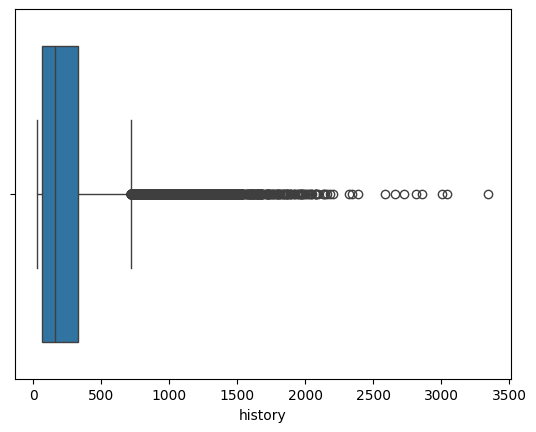

,count,mean,std,min,25%,50%,75%,max
recency,44800.000,5.754,3.508,1.000,2.000,5.000,9.000,12.000
history,44800.000,242.280,255.832,29.990,64.800,158.280,325.770,3345.930
mens,44800.000,0.550,0.498,0.000,0.000,1.000,1.000,1.000
womens,44800.000,0.551,0.497,0.000,0.000,1.000,1.000,1.000
newbie,44800.000,0.504,0.500,0.000,0.000,1.000,1.000,1.000
target,44800.000,0.147,0.354,0.000,0.000,0.000,0.000,1.000


In [67]:
sns.boxplot(x=df_train["history"])
plt.show() 

df_train.describe().T
# standart sapmanın ortalamadan büyük olması yüksek varyans yani verinin düzensizliği demektir.

In [68]:

def outlier_thresholds(dataframe, col_name, q1=0.01, q3=0.99):
    quartile1 = dataframe[col_name].quantile(q1)
    quartile3 = dataframe[col_name].quantile(q3)
    interquantile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range
    return low_limit, up_limit


def check_outlier(dataframe, col_name):
    low_limit, up_limit = outlier_thresholds(dataframe, col_name)
    if dataframe[(dataframe[col_name] > up_limit) | (dataframe[col_name] < low_limit)].any(axis=None):
        return True
    else:
        return False

check_outlier(df_train, "history")


True

In [69]:
def grab_outliers(dataframe, col_name, index=False):
    low, up = outlier_thresholds(dataframe, col_name)

    if dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].shape[0] > 10:
        print(dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].head())
    else:
        print(dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))])

    if index:
        outlier_index = dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].index
        return outlier_index

grab_outliers(df_train, "history", True) 
# sadece iki müşteri var ama harcamaları aşırı yüksek. bu kişileri direkt silersek değerli bir içgörü kaybolur.
# bunlara Whale denir. Sayıları çok azdır ama şirketin toplam cirosunun çok büyük bir kısmını tek başlarına sırtlarlar. 
# Bu insanların hangi kanalı kullandığı veya e-postalara nasıl tepki verdiği (target) şirket için altın değerindedir.

def replace_with_thresholds(dataframe, variable): # bunun yerine logaritmik dönüşüm de yapılabilir.
    low_limit, up_limit = outlier_thresholds(dataframe, variable)
    dataframe.loc[(dataframe[variable] < low_limit), variable] = low_limit
    dataframe.loc[(dataframe[variable] > up_limit), variable] = up_limit

replace_with_thresholds(df_train, "history")



       recency history_segment  history  mens  womens   zip_code  newbie channel  target      treatment
4579         2     7) $1,000 + 3345.930     1       1  Surburban       1   Phone       0      No E-Mail
52860        1     7) $1,000 + 3040.200     0       1      Urban       1     Web       0  Womens E-Mail


In [70]:
df_train.describe().T # max history değerimiz az da olsa düştü. çok düşerse gerçekliği yitirir.

,count,mean,std,min,25%,50%,75%,max
recency,44800.000,5.754,3.508,1.000,2.000,5.000,9.000,12.000
history,44800.000,242.272,255.744,29.990,64.800,158.280,325.770,3022.145
mens,44800.000,0.550,0.498,0.000,0.000,1.000,1.000,1.000
womens,44800.000,0.551,0.497,0.000,0.000,1.000,1.000,1.000
newbie,44800.000,0.504,0.500,0.000,0.000,1.000,1.000,1.000
target,44800.000,0.147,0.354,0.000,0.000,0.000,0.000,1.000


target
0   0.853
1   0.147
Name: proportion, dtype: float64


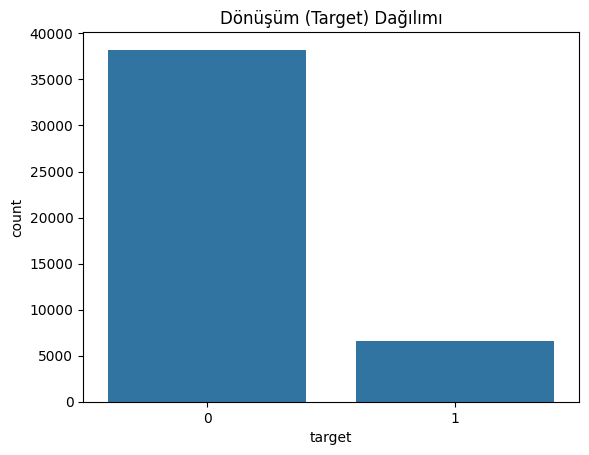

In [71]:
# Satın alma oranlarını yüzdesel olarak görelim
print(df_train['target'].value_counts(normalize=True))

sns.countplot(data=df_train, x='target')
plt.title("Dönüşüm (Target) Dağılımı")
plt.show()

In [72]:
# Gruplardaki insan sayıları
print(df_train['treatment'].value_counts())
print()
# Grupların yüzdesel oranları (A/B testi mantığı gereği %33 - %33 - %33 civarı çıkmalı)
print(df_train['treatment'].value_counts(normalize=True))

treatment
Womens E-Mail    15036
No E-Mail        14949
Mens E-Mail      14815
Name: count, dtype: int64

treatment
Womens E-Mail   0.336
No E-Mail       0.334
Mens E-Mail     0.331
Name: proportion, dtype: float64


channel
Multichannel   0.175
Phone          0.128
Web            0.157
Name: target, dtype: float64

zip_code
Rural       0.185
Surburban   0.141
Urban       0.139
Name: target, dtype: float64

            count    mean     std    min    25%     50%     75%      max
history 44800.000 242.272 255.744 29.990 64.800 158.280 325.770 3022.145
recency 44800.000   5.754   3.508  1.000  2.000   5.000   9.000   12.000


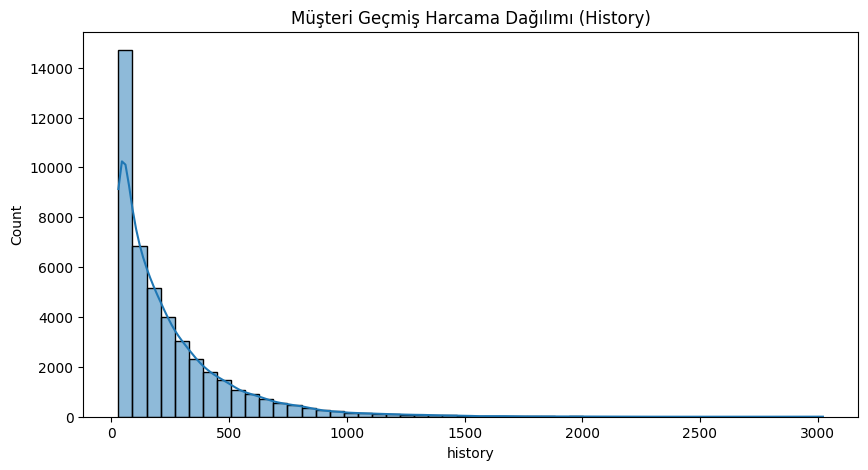

In [73]:
# Hangi alışveriş kanalını kullananların satın alma oranı daha yüksek?
print(df_train.groupby('channel')['target'].mean())
print()
# Hangi bölgede yaşayanların satın alma oranı daha yüksek?
print(df_train.groupby('zip_code')['target'].mean())
print()
# Sayısal sütunların genel istatistikleri
print(df_train[['history', 'recency']].describe().T)

# History sütununun dağılım grafiği - sağa çarpıklığı çıplak gözle göreceksin, yön tayini yapılırken tepe noktasına değil, kuyruğun uzadığı tarafa bakılır.
plt.figure(figsize=(10, 5))
sns.histplot(data=df_train, x='history', kde=True, bins=50)
plt.title("Müşteri Geçmiş Harcama Dağılımı (History)")
plt.show()

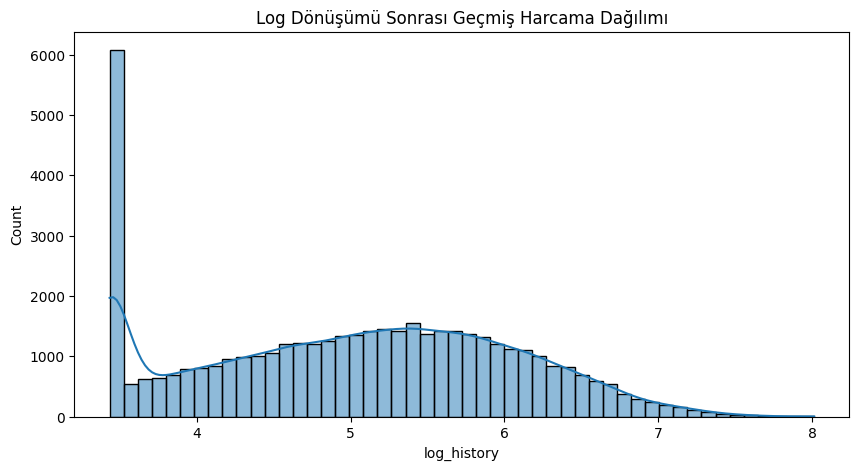

In [74]:
df_train['log_history'] = np.log1p(df_train['history']) #right-skewness'ı çözmek için. ridge bundan hoşlanmaz.

# Yeni dağılıma tekrar bakalım
plt.figure(figsize=(10, 5))
sns.histplot(data=df_train, x='log_history', kde=True, bins=50)
plt.title("Log Dönüşümü Sonrası Geçmiş Harcama Dağılımı")
plt.show()


In [75]:
df_train.drop(columns=['history_segment'], errors='ignore', inplace=True)

In [76]:
df_train.head()

,recency,history,mens,womens,zip_code,newbie,channel,target,treatment,log_history
36671,1,342.730,0,1,Surburban,1,Web,0,Womens E-Mail,5.840
24599,2,59.240,0,1,Surburban,0,Phone,1,Mens E-Mail,4.098
36611,4,138.060,0,1,Surburban,0,Web,1,Womens E-Mail,4.935
179,2,29.990,1,0,Urban,1,Web,0,Womens E-Mail,3.434
30598,3,185.950,1,0,Urban,0,Phone,0,Womens E-Mail,5.231


In [77]:
# A. Harcama Yoğunluğu, taze olanın sadakati daha yüksek.
df_train['spending_intensity'] = df_train['history'] / (df_train['recency'] + 1)

# B. Kategori Çeşitliliği, kampanya e-postalarına tepkisi tek bir kategoriye bakan kişiden çok farklı olur.
df_train['is_unisex_buyer'] = df_train['mens'] * df_train['womens']

# C. Dijital Segmentler, kampanyasının etkisini (uplift) hesaplarken eski dijitallerle yeni dijitalleri farklı skorlar vererek ikna etmeye çalışıyor.
df_train['digital_newbies'] = df_train['newbie'] * (df_train['channel'] == 'Web').astype(int)
df_train['digital_veterans'] = (1 - df_train['newbie']) * (df_train['channel'] == 'Web').astype(int)

# D. Şehir merkezinde yaşayıp web kullanan kitle, e-postalara anında reaksiyon göstermeye en müsait olan "hızlı tüketici" segmentidir.
df_train['urban_web_user'] = ((df_train['zip_code'] == 'Urban') & (df_train['channel'] == 'Web')).astype(int)

In [78]:
df_train.head()

,recency,history,mens,womens,zip_code,newbie,channel,target,treatment,log_history,spending_intensity,is_unisex_buyer,digital_newbies,digital_veterans,urban_web_user
36671,1,342.730,0,1,Surburban,1,Web,0,Womens E-Mail,5.840,171.365,0,1,0,0
24599,2,59.240,0,1,Surburban,0,Phone,1,Mens E-Mail,4.098,19.747,0,0,0,0
36611,4,138.060,0,1,Surburban,0,Web,1,Womens E-Mail,4.935,27.612,0,0,1,0
179,2,29.990,1,0,Urban,1,Web,0,Womens E-Mail,3.434,9.997,0,1,0,1
30598,3,185.950,1,0,Urban,0,Phone,0,Womens E-Mail,5.231,46.487,0,0,0,0


In [79]:
def one_hot_encoder(dataframe, categorical_cols, drop_first=True):
    dataframe = pd.get_dummies(dataframe, columns=categorical_cols, drop_first=drop_first, dtype=int) # drop_first=True, veri setin gereksiz yere şişmez, multicollinearity engeller
    return dataframe

ohe_cols = [col for col in df_train.columns if (df_train[col].dtype == 'O' or df_train[col].dtype.name == 'category') 
            and col not in ['target', 'treatment'] and 10 >= df[col].nunique() > 1]

df_train = one_hot_encoder(df_train, ohe_cols) 

# Gördüğün gibi, model ilk 4 kolonun değerini bildiği an, 5. kolonun ne olacağını (oraya bakmasına bile gerek kalmadan) matematiksel olarak %100 doğrulukla bulabilir. İşte bu durum mükemmel çoklu doğrusal bağlantıdır.
# Sen drop_first=False yaptığında, elindeki 5 kolonun toplamı (1) ile Intercept kolonunun kendisi (1) tamamen üst üste biner. Lineer cebirde buna bağımlı matris denir.

In [80]:
df_train.head()

,recency,history,mens,womens,newbie,target,treatment,log_history,spending_intensity,is_unisex_buyer,digital_newbies,digital_veterans,urban_web_user,zip_code_Surburban,zip_code_Urban,channel_Phone,channel_Web
36671,1,342.730,0,1,1,0,Womens E-Mail,5.840,171.365,0,1,0,0,1,0,0,1
24599,2,59.240,0,1,0,1,Mens E-Mail,4.098,19.747,0,0,0,0,1,0,1,0
36611,4,138.060,0,1,0,1,Womens E-Mail,4.935,27.612,0,0,1,0,1,0,0,1
179,2,29.990,1,0,1,0,Womens E-Mail,3.434,9.997,0,1,0,1,0,1,0,1
30598,3,185.950,1,0,0,0,Womens E-Mail,5.231,46.487,0,0,0,0,0,1,1,0
